# 5. Evaluation (Explainable AI with SHAP)
Pada tahap ini, kita mengevaluasi model LightGBM yang telah dilatih menggunakan metode **SHAP (SHapley Additive exPlanations)**. SHAP membantu kita menginterpretasikan keputusan model *machine learning* yang kompleks (seperti *black-box model*) dengan menunjukkan kontribusi dari setiap fitur (variabel) terhadap prediksi akhir.

In [25]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
from sklearn.model_selection import train_test_split

## 5.1 Load Data dan Model

In [26]:
df = pd.read_csv('../Datasets/prepared_dataset.csv')

# Convert categorical columns
cat_features = ['BP_History', 'Medication', 'Family_History', 'Exercise_Level', 'Smoking_Status']
for col in cat_features:
    df[col] = df[col].astype('category')

X = df.drop('Has_Hypertension', axis=1)
y = df['Has_Hypertension']

# Gunakan random_state yang sama untuk mendapatkan X_test yang persis sama
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Load Model
model = joblib.load('../Models/lightgbm_model.pkl')
print('Model LightGBM dan data uji berhasil dimuat.')

Model LightGBM dan data uji berhasil dimuat.


## 5.2 SHAP Explainer
Kita menginisialisasi `TreeExplainer` yang dioptimalkan secara khusus untuk model berbasis pohon (seperti LightGBM, XGBoost, Random Forest).

In [27]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

## 5.3 SHAP Summary Plot

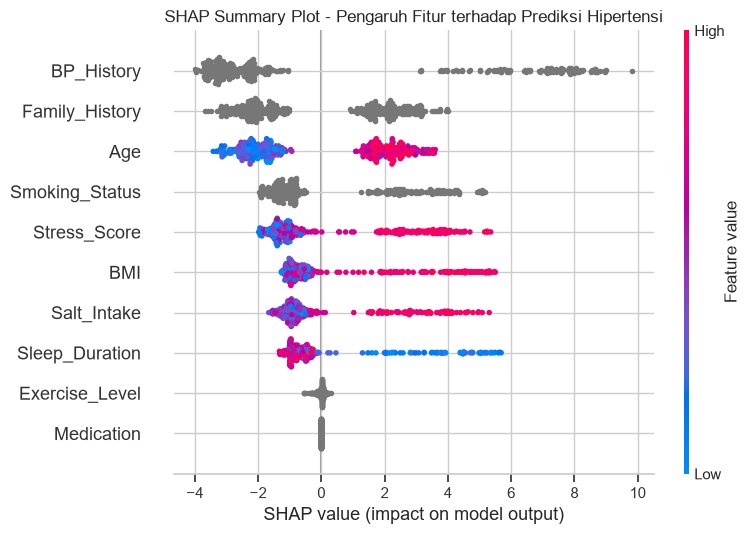

In [28]:
plt.figure()
shap.summary_plot(shap_values_plot, X_test, show=False)
plt.title('SHAP Summary Plot - Pengaruh Fitur terhadap Prediksi Hipertensi')
plt.tight_layout()
plt.show()

**Interpretasi Summary Plot (Beeswarm):**
- **Sumbu Y:** Menunjukkan daftar fitur yang diurutkan berdasarkan kepentingannya dari atas ke bawah.
- **Sumbu X (SHAP value):** Menunjukkan dampak fitur terhadap prediksi model. Titik di sebelah **kanan** (nilai SHAP > 0) berarti mendorong prediksi ke arah positif (berisiko Hipertensi), sedangkan di sebelah **kiri** (nilai SHAP < 0) mendorong prediksi ke arah negatif (Normal).
- **Warna Titik:** Warna merah menunjukkan nilai fitur tersebut tinggi, sedangkan warna biru menunjukkan nilai fitur tersebut rendah.
- **Contoh Analisis:** Jika pada baris `Salt_Intake` (Konsumsi Garam) banyak titik berwarna **merah** berkumpul di sebelah **kanan** sumbu X, ini secara gamblang mengindikasikan bahwa konsumsi garam yang tinggi secara signifikan meningkatkan probabilitas/risiko pasien terkena Hipertensi.

## 5.4 SHAP Feature Importance

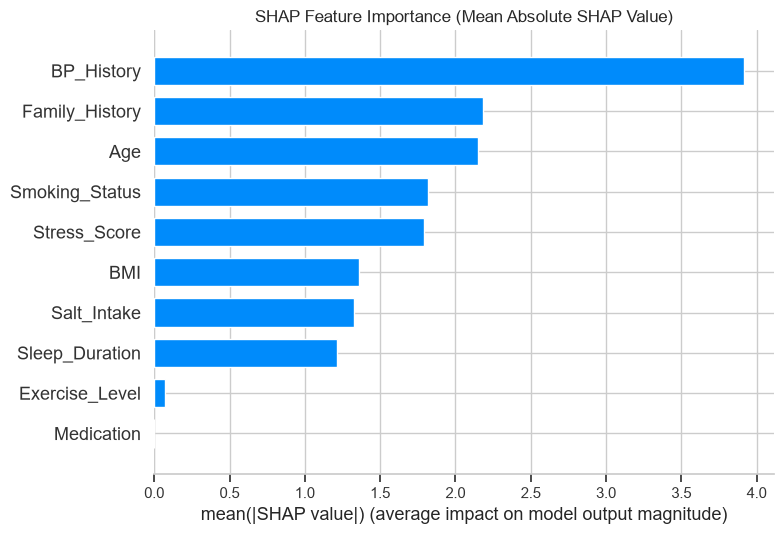

In [29]:
plt.figure()
shap.summary_plot(shap_values_plot, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean Absolute SHAP Value)')
plt.tight_layout()
plt.show()

**Interpretasi Feature Importance (Bar Plot):**
Plot ini adalah bentuk agregasi (rata-rata absolut) dari plot sebelumnya. Plot ini menyoroti **fitur mana yang paling penting** bagi model secara global. Semakin panjang bar suatu fitur, semakin besar kontribusi rata-rata fitur tersebut dalam mengubah prediksi model. Ini sangat berguna untuk menentukan prioritas faktor risiko utama (misalnya, jika `Salt_Intake` dan `Age` berada di puncak, berarti keduanya adalah faktor pendorong paling kuat untuk penyakit ini).

## 5.5 SHAP Dependence Plot

<Figure size 640x480 with 0 Axes>

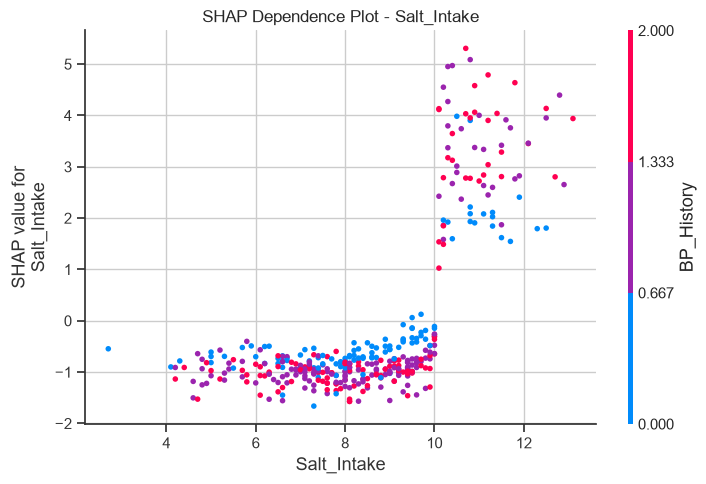

In [30]:
plt.figure()
shap.dependence_plot('Salt_Intake', shap_values_plot, X_test, show=False)
plt.title('SHAP Dependence Plot - Salt_Intake')
plt.tight_layout()
plt.show()

**Interpretasi Dependence Plot:**
Plot ini fokus pada satu fitur (dalam hal ini `Salt_Intake`) untuk melihat efek interaksinya secara lebih detail:
- **Sumbu X:** Merupakan nilai aktual dari konsumsi garam.
- **Sumbu Y:** Merupakan nilai SHAP (dampaknya terhadap prediksi).
Melalui plot ini, kita bisa melihat pola hubungan antara konsumsi garam dan risiko hipertensi, misalnya apakah risiko mulai naik tajam setelah melewati angka/batas konsumsi garam tertentu (threshold effect). Warna pada titik-titik tersebut biasanya menunjukkan fitur lain yang paling berinteraksi dengan `Salt_Intake`.

## 5.6 SHAP Waterfall Plot

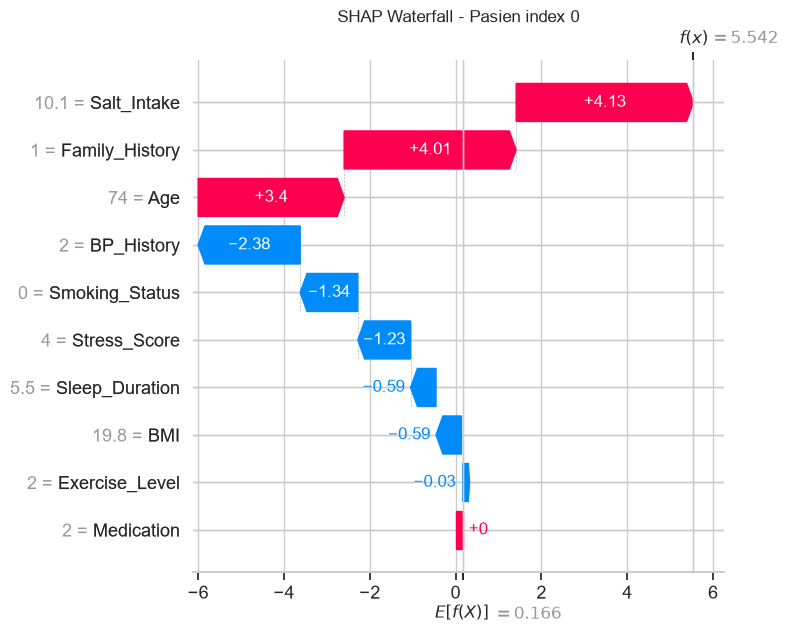

In [31]:
sample_idx = 0
explainer_exp = shap.Explainer(model)
shap_exp_values = explainer_exp(X_test)

plt.figure()
shap.plots.waterfall(shap_exp_values[sample_idx], show=False)
plt.title(f'SHAP Waterfall - Pasien index {sample_idx}')
plt.tight_layout()
plt.show()

**Interpretasi Waterfall Plot (Analisis Level Pasien Individu):**
Berbeda dengan plot sebelumnya yang bersifat global (seluruh dataset), plot ini bersifat **lokal** (hanya untuk satu pasien, dalam hal ini pasien indeks 0).
- Nilai di bagian bawah adalah rata-rata dasar prediksi model (base value/expected value) sebelum mempertimbangkan profil pasien.
- Nilai di bagian atas (f(x)) adalah prediksi akhir untuk pasien ini.
- Bar berwarna **Merah** (+): Fitur pasien tersebut meningkatkan risiko hipertensi.
- Bar berwarna **Biru** (-): Fitur pasien tersebut menurunkan risiko hipertensi.
Plot ini menjelaskan secara transparan *mengapa* model memberikan vonis hipertensi atau tidak kepada pasien tertentu.

## 5.7 Ranking Fitur Paling Berpengaruh

In [32]:
feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': np.abs(shap_values_plot).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False)

print("=== RANKING FITUR BERDASARKAN SHAP ===")
print(feature_importance)

=== RANKING FITUR BERDASARKAN SHAP ===
          Feature  Mean_Abs_SHAP
3      BP_History       3.919268
7  Family_History       2.183655
0             Age       2.149546
9  Smoking_Status       1.821195
2    Stress_Score       1.794558
5             BMI       1.361261
1     Salt_Intake       1.325747
4  Sleep_Duration       1.213803
8  Exercise_Level       0.069508
6      Medication       0.000000


**Kesimpulan Evaluasi Model (SHAP):**
Tabel di atas menyajikan angka pasti (kuantitatif) dari *Feature Importance*. Berdasarkan hasil analisis ini, kita dapat menarik simpulan akhir terkait faktor-faktor terpenting yang memicu hipertensi dalam dataset, serta memberikan rekomendasi tindakan atau intervensi kesehatan yang difokuskan pada variabel-variabel di peringkat teratas.